# Attention-Based GRU (ABGRU) for RUL Prediction

## All CMAPSS Datasets (FD001, FD002, FD003, FD004)

**Reference:** Lin, R., et al. (2023). "Attention-based Gate Recurrent Unit for remaining useful life prediction in prognostics". Applied Soft Computing, 143, 110419.

In [17]:
# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [18]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.metrics import f1_score, precision_score, recall_score, accuracy_score, confusion_matrix, classification_report
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import warnings
warnings.filterwarnings('ignore')

# Set random seeds
np.random.seed(42)
torch.manual_seed(42)
if torch.cuda.is_available():
    torch.cuda.manual_seed(42)

print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")

PyTorch version: 2.9.0+cu126
CUDA available: True
GPU: Tesla T4


In [19]:
# ============== CONFIGURATION ==============
BASE = "/content/drive/MyDrive/data"  # Update this path to your data folder

# All CMAPSS datasets
DATASETS = ['FD001', 'FD002', 'FD003', 'FD004']

# Dataset characteristics:
# FD001: 1 operating condition, 1 fault mode, 100 train engines, 100 test engines
# FD002: 6 operating conditions, 1 fault mode, 260 train engines, 259 test engines
# FD003: 1 operating condition, 2 fault modes, 100 train engines, 100 test engines
# FD004: 6 operating conditions, 2 fault modes, 249 train engines, 248 test engines

# Model hyperparameters
SEQUENCE_LENGTH = 30
HIDDEN_DIM = 64
NUM_LAYERS = 2
ATTENTION_DIM = 32
DROPOUT = 0.3
BATCH_SIZE = 64
NUM_EPOCHS = 100
LEARNING_RATE = 0.001
RUL_CLIP = 125

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

# Verify all data files exist
print(f"\nChecking data files in: {BASE}")
for dataset in DATASETS:
    print(f"\n{dataset}:")
    for f in [f'train_{dataset}.csv', f'test_{dataset}.csv', f'RUL_{dataset}.txt']:
        path = os.path.join(BASE, f)
        status = 'Found' if os.path.exists(path) else 'MISSING'
        print(f"  {f}: {status}")

Using device: cuda

Checking data files in: /content/drive/MyDrive/data

FD001:
  train_FD001.csv: Found
  test_FD001.csv: Found
  RUL_FD001.txt: Found

FD002:
  train_FD002.csv: Found
  test_FD002.csv: Found
  RUL_FD002.txt: Found

FD003:
  train_FD003.csv: Found
  test_FD003.csv: Found
  RUL_FD003.txt: Found

FD004:
  train_FD004.csv: Found
  test_FD004.csv: Found
  RUL_FD004.txt: Found


## 1. Data Processing Functions

In [20]:
def load_cmapss_data(base_path, dataset):
    """Load CMAPSS dataset from CSV files."""
    train_path = os.path.join(base_path, f"train_{dataset}.csv")
    test_path = os.path.join(base_path, f"test_{dataset}.csv")
    rul_path = os.path.join(base_path, f"RUL_{dataset}.txt")

    train_df = pd.read_csv(train_path)
    test_df = pd.read_csv(test_path)
    rul_df = pd.read_csv(rul_path, header=None, names=['RUL'])

    # Remove null/empty columns
    null_cols = [col for col in train_df.columns if train_df[col].isna().all()]
    train_df = train_df.drop(columns=null_cols)
    test_df = test_df.drop(columns=null_cols)

    return train_df, test_df, rul_df


def add_rul_column(df, rul_clip=None):
    """Add RUL column with piecewise linear degradation."""
    max_cycles = df.groupby('unit_number')['time_in_cycles'].max().reset_index()
    max_cycles.columns = ['unit_number', 'max_cycle']
    df = df.merge(max_cycles, on='unit_number')
    df['RUL'] = df['max_cycle'] - df['time_in_cycles']
    df.drop('max_cycle', axis=1, inplace=True)
    if rul_clip is not None:
        df['RUL'] = df['RUL'].clip(upper=rul_clip)
    return df


def get_feature_columns(df):
    """Get valid feature columns (remove constant columns)."""
    sensor_cols = [col for col in df.columns if 'sensor_measurement' in col]
    op_cols = [col for col in df.columns if 'operational_setting' in col]
    feature_cols = op_cols + sensor_cols
    variance = df[feature_cols].var()
    valid_cols = variance[variance > 1e-6].index.tolist()
    return valid_cols


def create_sequences(df, feature_cols, sequence_length, target_col='RUL'):
    """Create sequences for training using sliding window."""
    sequences, targets = [], []
    for unit_id in df['unit_number'].unique():
        unit_data = df[df['unit_number'] == unit_id].sort_values('time_in_cycles')
        features = unit_data[feature_cols].values
        rul_values = unit_data[target_col].values
        for i in range(len(features) - sequence_length + 1):
            sequences.append(features[i:i + sequence_length])
            targets.append(rul_values[i + sequence_length - 1])
    return np.array(sequences), np.array(targets)


def create_test_sequences(df, feature_cols, sequence_length, rul_df):
    """Create test sequences (last sequence_length cycles per engine)."""
    sequences = []
    targets = rul_df['RUL'].values
    for unit_id in sorted(df['unit_number'].unique()):
        unit_data = df[df['unit_number'] == unit_id].sort_values('time_in_cycles')
        features = unit_data[feature_cols].values
        if len(features) >= sequence_length:
            sequences.append(features[-sequence_length:])
        else:
            padded = np.zeros((sequence_length, features.shape[1]))
            padded[-len(features):] = features
            sequences.append(padded)
    return np.array(sequences), targets

## 2. Attention-Based GRU Model

In [21]:
class Attention(nn.Module):
    """Bahdanau-style Attention Mechanism."""
    def __init__(self, hidden_dim, attention_dim):
        super(Attention, self).__init__()
        self.W_h = nn.Linear(hidden_dim, attention_dim, bias=False)
        self.W_s = nn.Linear(hidden_dim, attention_dim, bias=False)
        self.v = nn.Linear(attention_dim, 1, bias=False)

    def forward(self, encoder_outputs, final_hidden):
        batch_size, seq_len, _ = encoder_outputs.size()
        encoder_proj = self.W_h(encoder_outputs)
        hidden_proj = self.W_s(final_hidden).unsqueeze(1).expand(-1, seq_len, -1)
        energy = torch.tanh(encoder_proj + hidden_proj)
        attention_scores = self.v(energy).squeeze(-1)
        attention_weights = torch.softmax(attention_scores, dim=1)
        context = torch.bmm(attention_weights.unsqueeze(1), encoder_outputs).squeeze(1)
        return context, attention_weights


class AttentionBasedGRU(nn.Module):
    """
    Attention-Based GRU (ABGRU) for RUL Prediction.

    Architecture:
    - Bidirectional GRU encoder
    - Bahdanau attention mechanism
    - Fully connected layers for regression
    """
    def __init__(self, input_dim, hidden_dim, num_layers, attention_dim, dropout=0.3):
        super(AttentionBasedGRU, self).__init__()

        self.gru = nn.GRU(
            input_size=input_dim,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            bidirectional=True,
            dropout=dropout if num_layers > 1 else 0
        )

        self.attention = Attention(hidden_dim * 2, attention_dim)

        self.fc = nn.Sequential(
            nn.Linear(hidden_dim * 2, hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, hidden_dim // 2),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim // 2, 1)
        )

        self.layer_norm = nn.LayerNorm(hidden_dim * 2)

    def forward(self, x):
        encoder_outputs, hidden = self.gru(x)
        hidden_forward = hidden[-2, :, :]
        hidden_backward = hidden[-1, :, :]
        final_hidden = torch.cat([hidden_forward, hidden_backward], dim=1)
        context, attention_weights = self.attention(encoder_outputs, final_hidden)
        context = self.layer_norm(context)
        rul_pred = self.fc(context)
        return rul_pred, attention_weights

## 3. Training and Evaluation Functions

In [22]:
def compute_score(y_true, y_pred):
    """PHM08 scoring function (asymmetric - penalizes late predictions more)."""
    d = y_pred - y_true
    return np.sum(np.where(d < 0, np.exp(-d/13) - 1, np.exp(d/10) - 1))


def compute_classification_metrics(y_true, y_pred, thresholds=[30, 60]):
    """
    Convert RUL regression to classification and compute F1, Precision, Recall.

    Classification schemes:
    1. Binary: Will engine fail soon? (RUL < threshold)
    2. Multi-class: Health states (Critical, Warning, Normal)

    Args:
        y_true: True RUL values
        y_pred: Predicted RUL values
        thresholds: [critical_threshold, warning_threshold]

    Returns:
        Dictionary with classification metrics
    """
    critical_thresh, warning_thresh = thresholds

    # ============ Binary Classification ============
    # Predict if engine will fail within critical_threshold cycles
    y_true_binary = (y_true < critical_thresh).astype(int)
    y_pred_binary = (y_pred < critical_thresh).astype(int)

    binary_metrics = {
        'Binary_Accuracy': accuracy_score(y_true_binary, y_pred_binary),
        'Binary_Precision': precision_score(y_true_binary, y_pred_binary, zero_division=0),
        'Binary_Recall': recall_score(y_true_binary, y_pred_binary, zero_division=0),
        'Binary_F1': f1_score(y_true_binary, y_pred_binary, zero_division=0)
    }

    # ============ Multi-class Classification ============
    # 0: Critical (RUL < 30), 1: Warning (30 <= RUL < 60), 2: Normal (RUL >= 60)
    def rul_to_class(rul, thresh1, thresh2):
        if rul < thresh1:
            return 0  # Critical
        elif rul < thresh2:
            return 1  # Warning
        else:
            return 2  # Normal

    y_true_multi = np.array([rul_to_class(r, critical_thresh, warning_thresh) for r in y_true])
    y_pred_multi = np.array([rul_to_class(r, critical_thresh, warning_thresh) for r in y_pred])

    multiclass_metrics = {
        'Multi_Accuracy': accuracy_score(y_true_multi, y_pred_multi),
        'Multi_Precision_Macro': precision_score(y_true_multi, y_pred_multi, average='macro', zero_division=0),
        'Multi_Recall_Macro': recall_score(y_true_multi, y_pred_multi, average='macro', zero_division=0),
        'Multi_F1_Macro': f1_score(y_true_multi, y_pred_multi, average='macro', zero_division=0),
        'Multi_F1_Weighted': f1_score(y_true_multi, y_pred_multi, average='weighted', zero_division=0),
        # Per-class F1 scores
        'F1_Critical': f1_score(y_true_multi, y_pred_multi, labels=[0], average='micro', zero_division=0),
        'F1_Warning': f1_score(y_true_multi, y_pred_multi, labels=[1], average='micro', zero_division=0),
        'F1_Normal': f1_score(y_true_multi, y_pred_multi, labels=[2], average='micro', zero_division=0)
    }

    # Combine all metrics
    all_metrics = {**binary_metrics, **multiclass_metrics}

    # Store confusion matrix and class arrays for visualization
    all_metrics['confusion_matrix'] = confusion_matrix(y_true_multi, y_pred_multi)
    all_metrics['y_true_multi'] = y_true_multi
    all_metrics['y_pred_multi'] = y_pred_multi

    return all_metrics


def train_model(model, train_loader, val_loader, num_epochs, learning_rate, device, patience=15, verbose=True):
    """Train ABGRU model with early stopping."""
    criterion = nn.MSELoss()
    optimizer = optim.Adam(model.parameters(), lr=learning_rate, weight_decay=1e-5)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=5)

    train_losses, val_losses = [], []
    best_val_loss = float('inf')
    patience_counter = 0
    best_model_state = None

    for epoch in range(num_epochs):
        # Training
        model.train()
        train_loss = 0.0
        for batch_x, batch_y in train_loader:
            batch_x, batch_y = batch_x.to(device), batch_y.to(device)
            optimizer.zero_grad()
            predictions, _ = model(batch_x)
            loss = criterion(predictions.squeeze(), batch_y)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()
            train_loss += loss.item()
        train_loss /= len(train_loader)
        train_losses.append(train_loss)

        # Validation
        model.eval()
        val_loss = 0.0
        with torch.no_grad():
            for batch_x, batch_y in val_loader:
                batch_x, batch_y = batch_x.to(device), batch_y.to(device)
                predictions, _ = model(batch_x)
                loss = criterion(predictions.squeeze(), batch_y)
                val_loss += loss.item()
        val_loss /= len(val_loader)
        val_losses.append(val_loss)

        scheduler.step(val_loss)

        # Early stopping
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            patience_counter = 0
            best_model_state = model.state_dict().copy()
        else:
            patience_counter += 1

        if verbose and (epoch + 1) % 10 == 0:
            print(f"  Epoch [{epoch+1:3d}/{num_epochs}] | Train: {train_loss:.4f} | Val: {val_loss:.4f}")

        if patience_counter >= patience:
            if verbose:
                print(f"  Early stopping at epoch {epoch+1}")
            break

    if best_model_state:
        model.load_state_dict(best_model_state)

    return model, train_losses, val_losses


def evaluate_model(model, test_loader, device):
    """Evaluate model on test set with regression and classification metrics."""
    model.eval()
    predictions, targets, attention_weights = [], [], []

    with torch.no_grad():
        for batch_x, batch_y in test_loader:
            batch_x = batch_x.to(device)
            pred, attn = model(batch_x)
            predictions.extend(pred.squeeze().cpu().numpy())
            targets.extend(batch_y.numpy())
            attention_weights.extend(attn.cpu().numpy())

    predictions = np.array(predictions)
    targets = np.array(targets)
    attention_weights = np.array(attention_weights)

    # Regression metrics
    regression_metrics = {
        'RMSE': np.sqrt(mean_squared_error(targets, predictions)),
        'MAE': mean_absolute_error(targets, predictions),
        'R2': r2_score(targets, predictions),
        'Score': compute_score(targets, predictions)
    }

    # Classification metrics (F1, Precision, Recall)
    classification_metrics = compute_classification_metrics(targets, predictions)

    # Combine all metrics
    metrics = {**regression_metrics, **classification_metrics}

    return predictions, targets, attention_weights, metrics

## 4. Run ABGRU on All Datasets

In [23]:
def run_abgru_on_dataset(dataset, base_path, device, config):
    """
    Run complete ABGRU pipeline on a single dataset.

    Returns: metrics, predictions, targets, attention_weights, model
    """
    print(f"\n{'='*60}")
    print(f"DATASET: {dataset}")
    print(f"{'='*60}")

    # Load data
    print("Loading data...")
    train_df, test_df, rul_df = load_cmapss_data(base_path, dataset)
    print(f"  Train samples: {len(train_df)}, Test engines: {test_df['unit_number'].nunique()}")

    # Preprocess
    train_df = add_rul_column(train_df, rul_clip=config['rul_clip'])
    feature_cols = get_feature_columns(train_df)
    print(f"  Features: {len(feature_cols)}")

    # Normalize
    scaler = MinMaxScaler()
    train_df[feature_cols] = scaler.fit_transform(train_df[feature_cols])
    test_df[feature_cols] = scaler.transform(test_df[feature_cols])

    # Create sequences
    print("Creating sequences...")
    X_train, y_train = create_sequences(train_df, feature_cols, config['sequence_length'])
    X_test, y_test = create_test_sequences(test_df, feature_cols, config['sequence_length'], rul_df)
    print(f"  Train sequences: {X_train.shape}, Test sequences: {X_test.shape}")

    # Split and create dataloaders
    X_train_split, X_val, y_train_split, y_val = train_test_split(
        X_train, y_train, test_size=0.2, random_state=42
    )

    train_loader = DataLoader(
        TensorDataset(torch.FloatTensor(X_train_split), torch.FloatTensor(y_train_split)),
        batch_size=config['batch_size'], shuffle=True
    )
    val_loader = DataLoader(
        TensorDataset(torch.FloatTensor(X_val), torch.FloatTensor(y_val)),
        batch_size=config['batch_size'], shuffle=False
    )
    test_loader = DataLoader(
        TensorDataset(torch.FloatTensor(X_test), torch.FloatTensor(y_test)),
        batch_size=config['batch_size'], shuffle=False
    )

    # Initialize model
    input_dim = X_train.shape[2]
    model = AttentionBasedGRU(
        input_dim=input_dim,
        hidden_dim=config['hidden_dim'],
        num_layers=config['num_layers'],
        attention_dim=config['attention_dim'],
        dropout=config['dropout']
    ).to(device)

    # Train
    print("Training...")
    model, train_losses, val_losses = train_model(
        model, train_loader, val_loader,
        config['num_epochs'], config['learning_rate'],
        device, patience=15, verbose=True
    )

    # Evaluate
    print("Evaluating...")
    predictions, targets, attention_weights, metrics = evaluate_model(model, test_loader, device)

    print(f"\nResults for {dataset}:")
    print(f"  --- Regression Metrics ---")
    print(f"  RMSE:  {metrics['RMSE']:.2f}")
    print(f"  MAE:   {metrics['MAE']:.2f}")
    print(f"  R2:    {metrics['R2']:.4f}")
    print(f"  Score: {metrics['Score']:.2f}")
    print(f"  --- Classification Metrics (Binary: RUL<30) ---")
    print(f"  Binary Accuracy:   {metrics['Binary_Accuracy']:.4f}")
    print(f"  Binary Precision:  {metrics['Binary_Precision']:.4f}")
    print(f"  Binary Recall:     {metrics['Binary_Recall']:.4f}")
    print(f"  Binary F1:         {metrics['Binary_F1']:.4f}")
    print(f"  --- Multi-class Metrics (Critical/Warning/Normal) ---")
    print(f"  Multi-class Accuracy:  {metrics['Multi_Accuracy']:.4f}")
    print(f"  Multi-class F1 Macro:  {metrics['Multi_F1_Macro']:.4f}")
    print(f"  Multi-class F1 Weighted: {metrics['Multi_F1_Weighted']:.4f}")
    print(f"  F1 Critical (RUL<30):  {metrics['F1_Critical']:.4f}")
    print(f"  F1 Warning (30-60):    {metrics['F1_Warning']:.4f}")
    print(f"  F1 Normal (RUL>=60):   {metrics['F1_Normal']:.4f}")

    return {
        'metrics': metrics,
        'predictions': predictions,
        'targets': targets,
        'attention_weights': attention_weights,
        'model': model,
        'train_losses': train_losses,
        'val_losses': val_losses
    }

In [24]:
# Configuration
config = {
    'sequence_length': SEQUENCE_LENGTH,
    'hidden_dim': HIDDEN_DIM,
    'num_layers': NUM_LAYERS,
    'attention_dim': ATTENTION_DIM,
    'dropout': DROPOUT,
    'batch_size': BATCH_SIZE,
    'num_epochs': NUM_EPOCHS,
    'learning_rate': LEARNING_RATE,
    'rul_clip': RUL_CLIP
}

# Run on all datasets
all_results = {}

for dataset in DATASETS:
    try:
        results = run_abgru_on_dataset(dataset, BASE, device, config)
        all_results[dataset] = results
    except Exception as e:
        print(f"\nError processing {dataset}: {str(e)}")
        continue


DATASET: FD001
Loading data...
  Train samples: 20631, Test engines: 100
  Features: 16
Creating sequences...
  Train sequences: (17731, 30, 16), Test sequences: (100, 30, 16)
Training...
  Epoch [ 10/100] | Train: 422.2524 | Val: 179.5943
  Epoch [ 20/100] | Train: 381.7692 | Val: 161.5225
  Epoch [ 30/100] | Train: 367.5570 | Val: 161.9120
  Epoch [ 40/100] | Train: 354.0432 | Val: 147.7871
  Epoch [ 50/100] | Train: 335.8824 | Val: 137.3390
  Epoch [ 60/100] | Train: 321.6727 | Val: 135.3555
  Epoch [ 70/100] | Train: 321.0620 | Val: 132.8633
  Epoch [ 80/100] | Train: 313.1899 | Val: 130.2565
  Epoch [ 90/100] | Train: 318.3150 | Val: 129.9954
  Early stopping at epoch 91
Evaluating...

Results for FD001:
  --- Regression Metrics ---
  RMSE:  13.54
  MAE:   10.32
  R2:    0.8938
  Score: 279.85
  --- Classification Metrics (Binary: RUL<30) ---
  Binary Accuracy:   0.9300
  Binary Precision:  0.9091
  Binary Recall:     0.8000
  Binary F1:         0.8511
  --- Multi-class Metrics (

## 5. Results Summary

In [25]:
# Create summary tables
print("\n" + "="*100)
print("ABGRU RESULTS SUMMARY - ALL DATASETS")
print("="*100)

# Regression Metrics Table
print("\n--- REGRESSION METRICS ---")
summary_data = []
for dataset in DATASETS:
    if dataset in all_results:
        m = all_results[dataset]['metrics']
        summary_data.append({
            'Dataset': dataset,
            'RMSE': m['RMSE'],
            'MAE': m['MAE'],
            'R2': m['R2'],
            'Score': m['Score']
        })

summary_df = pd.DataFrame(summary_data)
print(summary_df.to_string(index=False))

# Classification Metrics Table (Binary)
print("\n--- BINARY CLASSIFICATION METRICS (Failure within 30 cycles) ---")
binary_data = []
for dataset in DATASETS:
    if dataset in all_results:
        m = all_results[dataset]['metrics']
        binary_data.append({
            'Dataset': dataset,
            'Accuracy': m['Binary_Accuracy'],
            'Precision': m['Binary_Precision'],
            'Recall': m['Binary_Recall'],
            'F1': m['Binary_F1']
        })

binary_df = pd.DataFrame(binary_data)
print(binary_df.to_string(index=False))

# Multi-class Metrics Table
print("\n--- MULTI-CLASS CLASSIFICATION METRICS (Critical/Warning/Normal) ---")
multi_data = []
for dataset in DATASETS:
    if dataset in all_results:
        m = all_results[dataset]['metrics']
        multi_data.append({
            'Dataset': dataset,
            'Accuracy': m['Multi_Accuracy'],
            'F1_Macro': m['Multi_F1_Macro'],
            'F1_Weighted': m['Multi_F1_Weighted'],
            'F1_Critical': m['F1_Critical'],
            'F1_Warning': m['F1_Warning'],
            'F1_Normal': m['F1_Normal']
        })

multi_df = pd.DataFrame(multi_data)
print(multi_df.to_string(index=False))

print("\n" + "-"*100)
print("Health State Thresholds: Critical (RUL<30), Warning (30<=RUL<60), Normal (RUL>=60)")
print("-"*100)
print("Comparison with Literature (Lin et al., 2023):")
print("Dataset | Literature RMSE | Literature Score")
print("FD001   | 12.83           | 221.54")
print("FD003   | 13.23           | 279.18")
print("="*100)


ABGRU RESULTS SUMMARY - ALL DATASETS

--- REGRESSION METRICS ---
Dataset      RMSE       MAE       R2        Score
  FD001 13.539494 10.321123 0.893844 2.798465e+02
  FD002 31.694450 21.364698 0.652668 2.571909e+04
  FD003 13.359574  9.734101 0.895846 2.429668e+02
  FD004 39.660676 26.047836 0.470887 1.126946e+06

--- BINARY CLASSIFICATION METRICS (Failure within 30 cycles) ---
Dataset  Accuracy  Precision   Recall       F1
  FD001  0.930000   0.909091 0.800000 0.851064
  FD002  0.980695   0.950820 0.966667 0.958678
  FD003  0.990000   0.952381 1.000000 0.975610
  FD004  0.927419   0.774194 0.923077 0.842105

--- MULTI-CLASS CLASSIFICATION METRICS (Critical/Warning/Normal) ---
Dataset  Accuracy  F1_Macro  F1_Weighted  F1_Critical  F1_Warning  F1_Normal
  FD001  0.860000  0.765021     0.858606     0.851064    0.500000   0.944000
  FD002  0.903475  0.864593     0.902973     0.958678    0.698795   0.936306
  FD003  0.930000  0.915374     0.927930     0.975610    0.820513   0.950000
  FD0

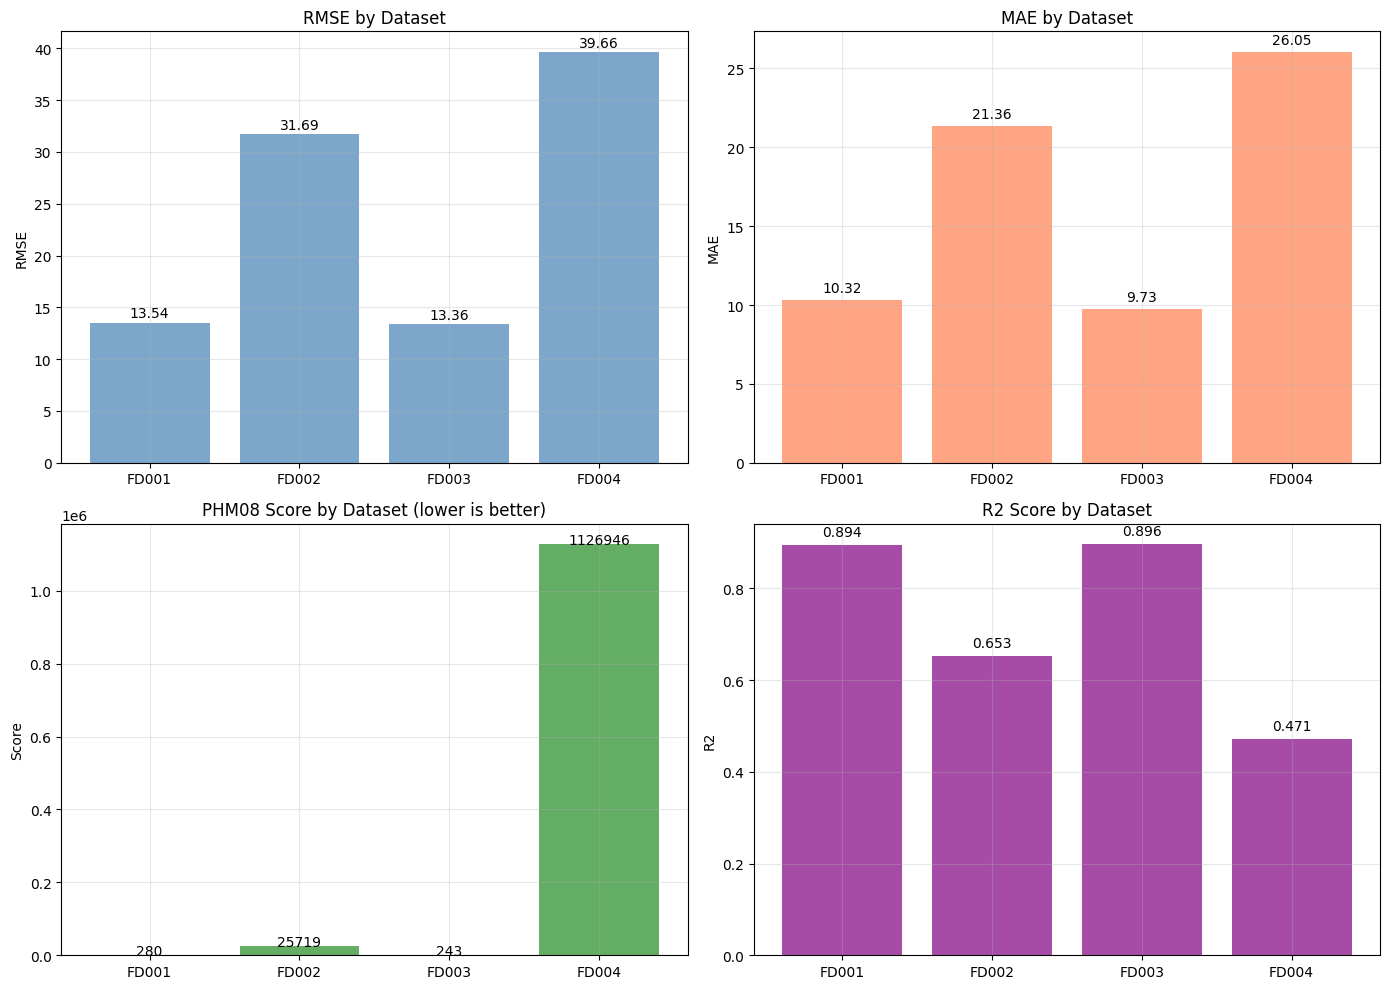

In [26]:
# Visualization: Regression Metrics comparison
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

datasets_with_results = [d for d in DATASETS if d in all_results]

# RMSE comparison
rmse_values = [all_results[d]['metrics']['RMSE'] for d in datasets_with_results]
axes[0, 0].bar(datasets_with_results, rmse_values, color='steelblue', alpha=0.7)
axes[0, 0].set_ylabel('RMSE')
axes[0, 0].set_title('RMSE by Dataset')
axes[0, 0].grid(True, alpha=0.3)
for i, v in enumerate(rmse_values):
    axes[0, 0].text(i, v + 0.5, f'{v:.2f}', ha='center')

# MAE comparison
mae_values = [all_results[d]['metrics']['MAE'] for d in datasets_with_results]
axes[0, 1].bar(datasets_with_results, mae_values, color='coral', alpha=0.7)
axes[0, 1].set_ylabel('MAE')
axes[0, 1].set_title('MAE by Dataset')
axes[0, 1].grid(True, alpha=0.3)
for i, v in enumerate(mae_values):
    axes[0, 1].text(i, v + 0.5, f'{v:.2f}', ha='center')

# Score comparison
score_values = [all_results[d]['metrics']['Score'] for d in datasets_with_results]
axes[1, 0].bar(datasets_with_results, score_values, color='forestgreen', alpha=0.7)
axes[1, 0].set_ylabel('Score')
axes[1, 0].set_title('PHM08 Score by Dataset (lower is better)')
axes[1, 0].grid(True, alpha=0.3)
for i, v in enumerate(score_values):
    axes[1, 0].text(i, v + 50, f'{v:.0f}', ha='center')

# R2 comparison
r2_values = [all_results[d]['metrics']['R2'] for d in datasets_with_results]
axes[1, 1].bar(datasets_with_results, r2_values, color='purple', alpha=0.7)
axes[1, 1].set_ylabel('R2')
axes[1, 1].set_title('R2 Score by Dataset')
axes[1, 1].grid(True, alpha=0.3)
for i, v in enumerate(r2_values):
    axes[1, 1].text(i, v + 0.02, f'{v:.3f}', ha='center')

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/abgru_regression_metrics.png', dpi=150, bbox_inches='tight')
plt.show()

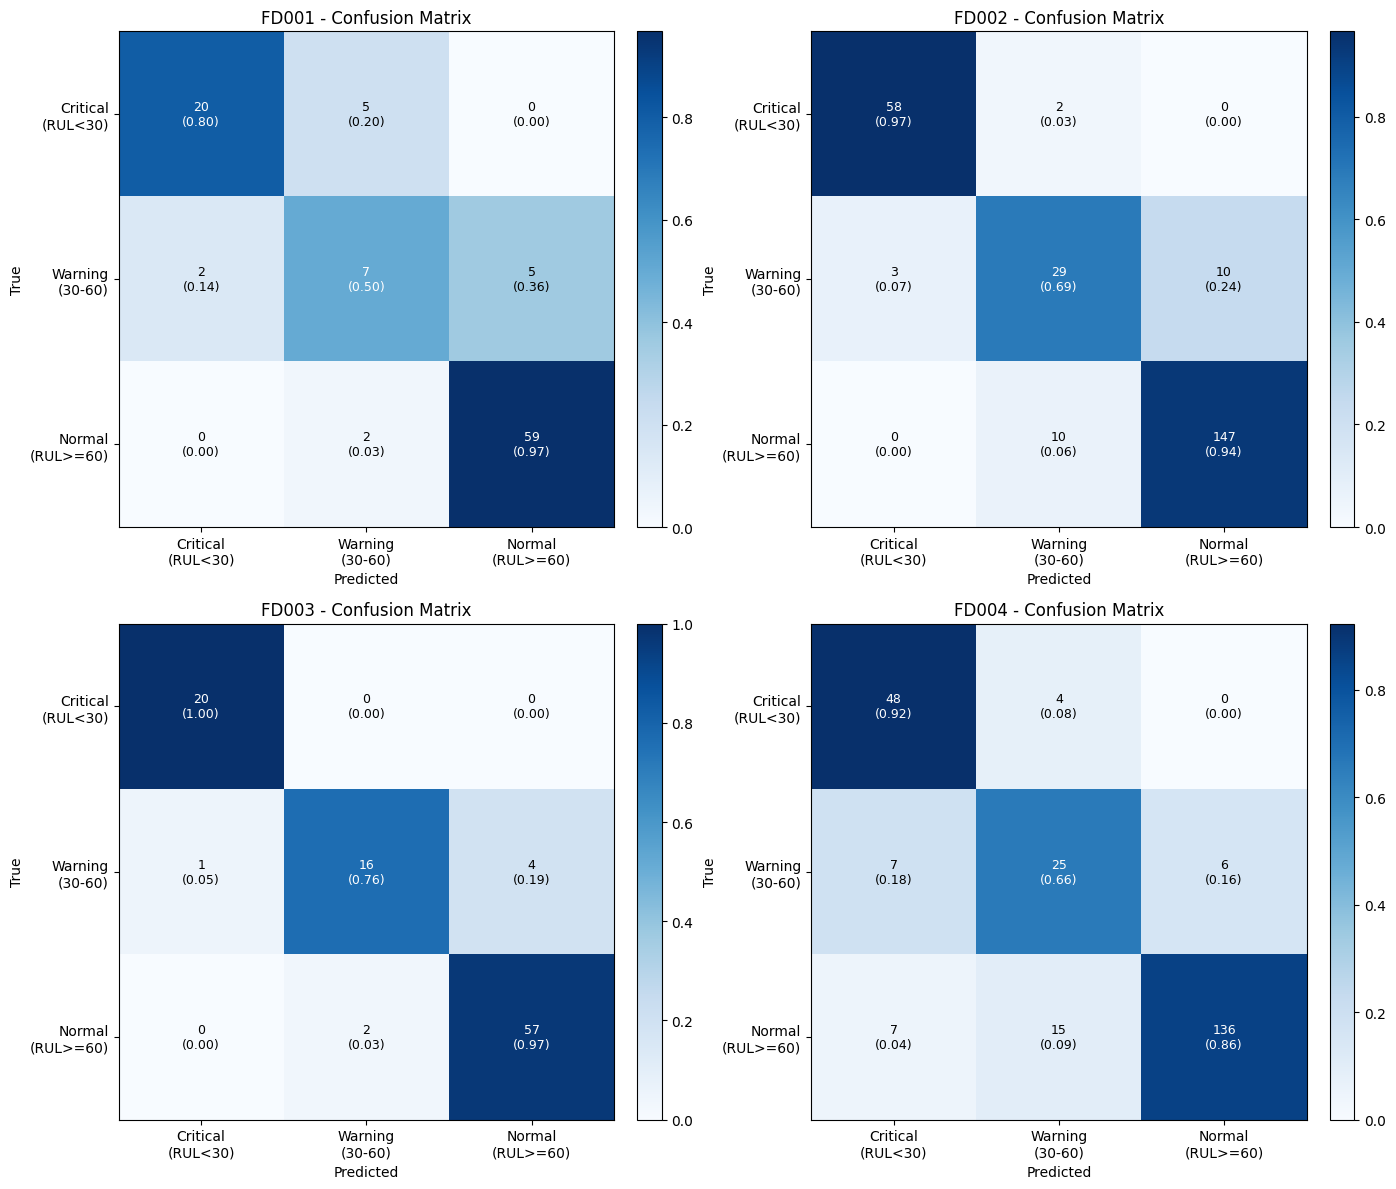

In [27]:
# Confusion Matrices for all datasets
fig, axes = plt.subplots(2, 2, figsize=(14, 12))
axes = axes.flatten()

class_names = ['Critical\n(RUL<30)', 'Warning\n(30-60)', 'Normal\n(RUL>=60)']

for idx, dataset in enumerate(datasets_with_results):
    if idx >= 4:
        break

    cm = all_results[dataset]['metrics']['confusion_matrix']

    # Normalize confusion matrix
    cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

    im = axes[idx].imshow(cm_normalized, interpolation='nearest', cmap='Blues')
    axes[idx].set_title(f'{dataset} - Confusion Matrix')

    # Add colorbar
    plt.colorbar(im, ax=axes[idx], fraction=0.046, pad=0.04)

    # Add labels
    axes[idx].set_xticks(np.arange(len(class_names)))
    axes[idx].set_yticks(np.arange(len(class_names)))
    axes[idx].set_xticklabels(class_names)
    axes[idx].set_yticklabels(class_names)
    axes[idx].set_xlabel('Predicted')
    axes[idx].set_ylabel('True')

    # Add text annotations
    thresh = cm_normalized.max() / 2.
    for i in range(len(class_names)):
        for j in range(len(class_names)):
            axes[idx].text(j, i, f'{cm[i, j]}\n({cm_normalized[i, j]:.2f})',
                          ha='center', va='center',
                          color='white' if cm_normalized[i, j] > thresh else 'black',
                          fontsize=9)

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/abgru_confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()

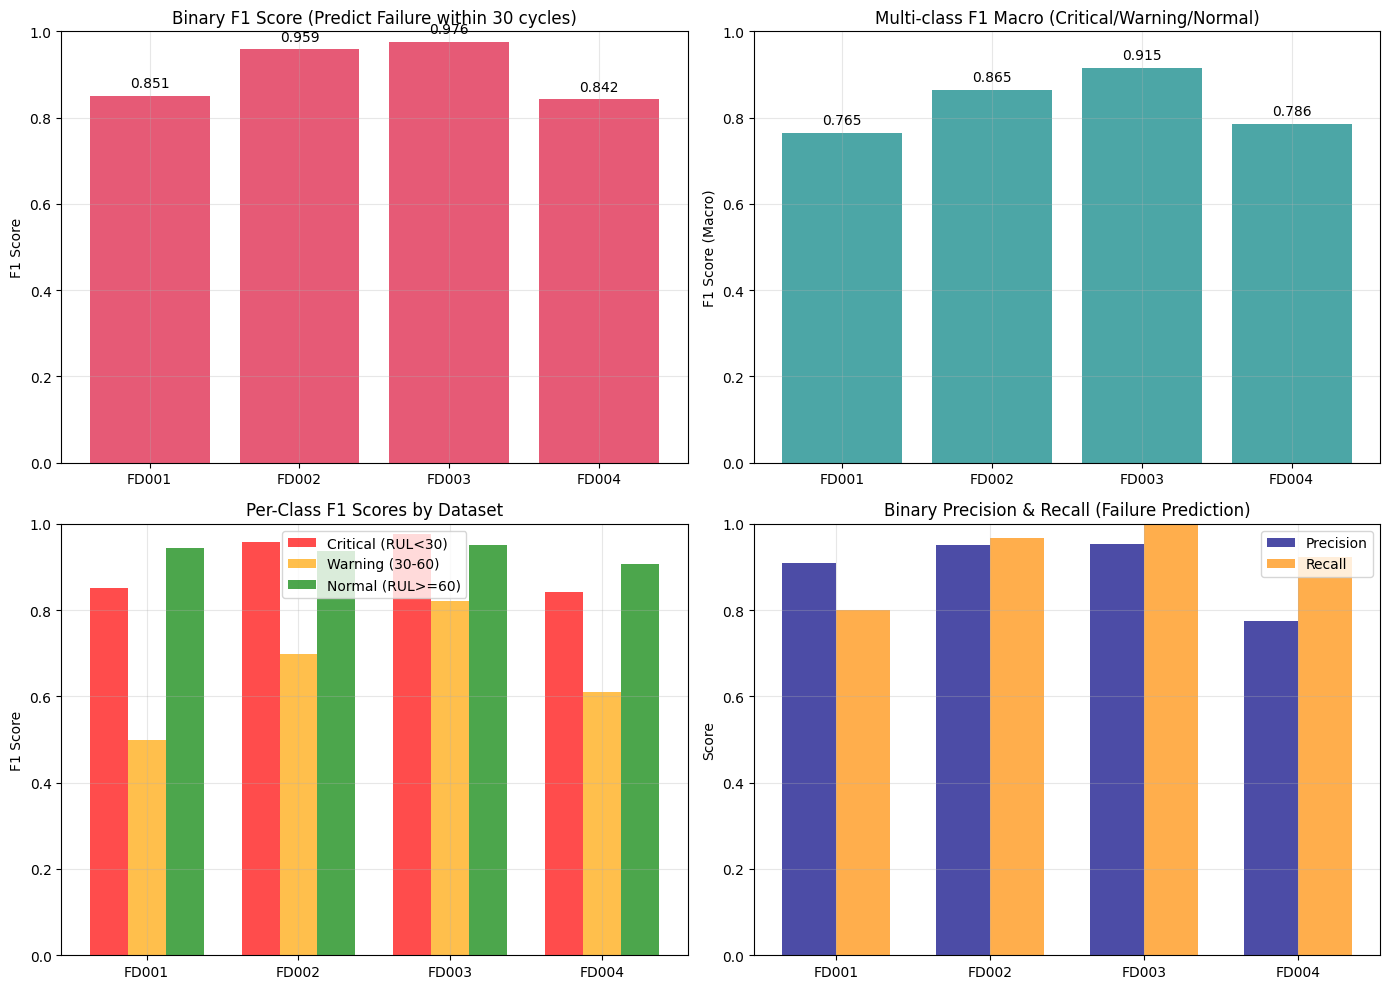

In [28]:
# Visualization: F1 Scores Comparison
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Binary F1 Score
binary_f1 = [all_results[d]['metrics']['Binary_F1'] for d in datasets_with_results]
axes[0, 0].bar(datasets_with_results, binary_f1, color='crimson', alpha=0.7)
axes[0, 0].set_ylabel('F1 Score')
axes[0, 0].set_title('Binary F1 Score (Predict Failure within 30 cycles)')
axes[0, 0].set_ylim(0, 1)
axes[0, 0].grid(True, alpha=0.3)
for i, v in enumerate(binary_f1):
    axes[0, 0].text(i, v + 0.02, f'{v:.3f}', ha='center')

# Multi-class F1 Macro
multi_f1_macro = [all_results[d]['metrics']['Multi_F1_Macro'] for d in datasets_with_results]
axes[0, 1].bar(datasets_with_results, multi_f1_macro, color='teal', alpha=0.7)
axes[0, 1].set_ylabel('F1 Score (Macro)')
axes[0, 1].set_title('Multi-class F1 Macro (Critical/Warning/Normal)')
axes[0, 1].set_ylim(0, 1)
axes[0, 1].grid(True, alpha=0.3)
for i, v in enumerate(multi_f1_macro):
    axes[0, 1].text(i, v + 0.02, f'{v:.3f}', ha='center')

# Per-class F1 scores grouped bar chart
x = np.arange(len(datasets_with_results))
width = 0.25

f1_critical = [all_results[d]['metrics']['F1_Critical'] for d in datasets_with_results]
f1_warning = [all_results[d]['metrics']['F1_Warning'] for d in datasets_with_results]
f1_normal = [all_results[d]['metrics']['F1_Normal'] for d in datasets_with_results]

axes[1, 0].bar(x - width, f1_critical, width, label='Critical (RUL<30)', color='red', alpha=0.7)
axes[1, 0].bar(x, f1_warning, width, label='Warning (30-60)', color='orange', alpha=0.7)
axes[1, 0].bar(x + width, f1_normal, width, label='Normal (RUL>=60)', color='green', alpha=0.7)
axes[1, 0].set_ylabel('F1 Score')
axes[1, 0].set_title('Per-Class F1 Scores by Dataset')
axes[1, 0].set_xticks(x)
axes[1, 0].set_xticklabels(datasets_with_results)
axes[1, 0].set_ylim(0, 1)
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

# Precision and Recall comparison
precision = [all_results[d]['metrics']['Binary_Precision'] for d in datasets_with_results]
recall = [all_results[d]['metrics']['Binary_Recall'] for d in datasets_with_results]

x = np.arange(len(datasets_with_results))
width = 0.35

axes[1, 1].bar(x - width/2, precision, width, label='Precision', color='navy', alpha=0.7)
axes[1, 1].bar(x + width/2, recall, width, label='Recall', color='darkorange', alpha=0.7)
axes[1, 1].set_ylabel('Score')
axes[1, 1].set_title('Binary Precision & Recall (Failure Prediction)')
axes[1, 1].set_xticks(x)
axes[1, 1].set_xticklabels(datasets_with_results)
axes[1, 1].set_ylim(0, 1)
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/abgru_f1_scores.png', dpi=150, bbox_inches='tight')
plt.show()

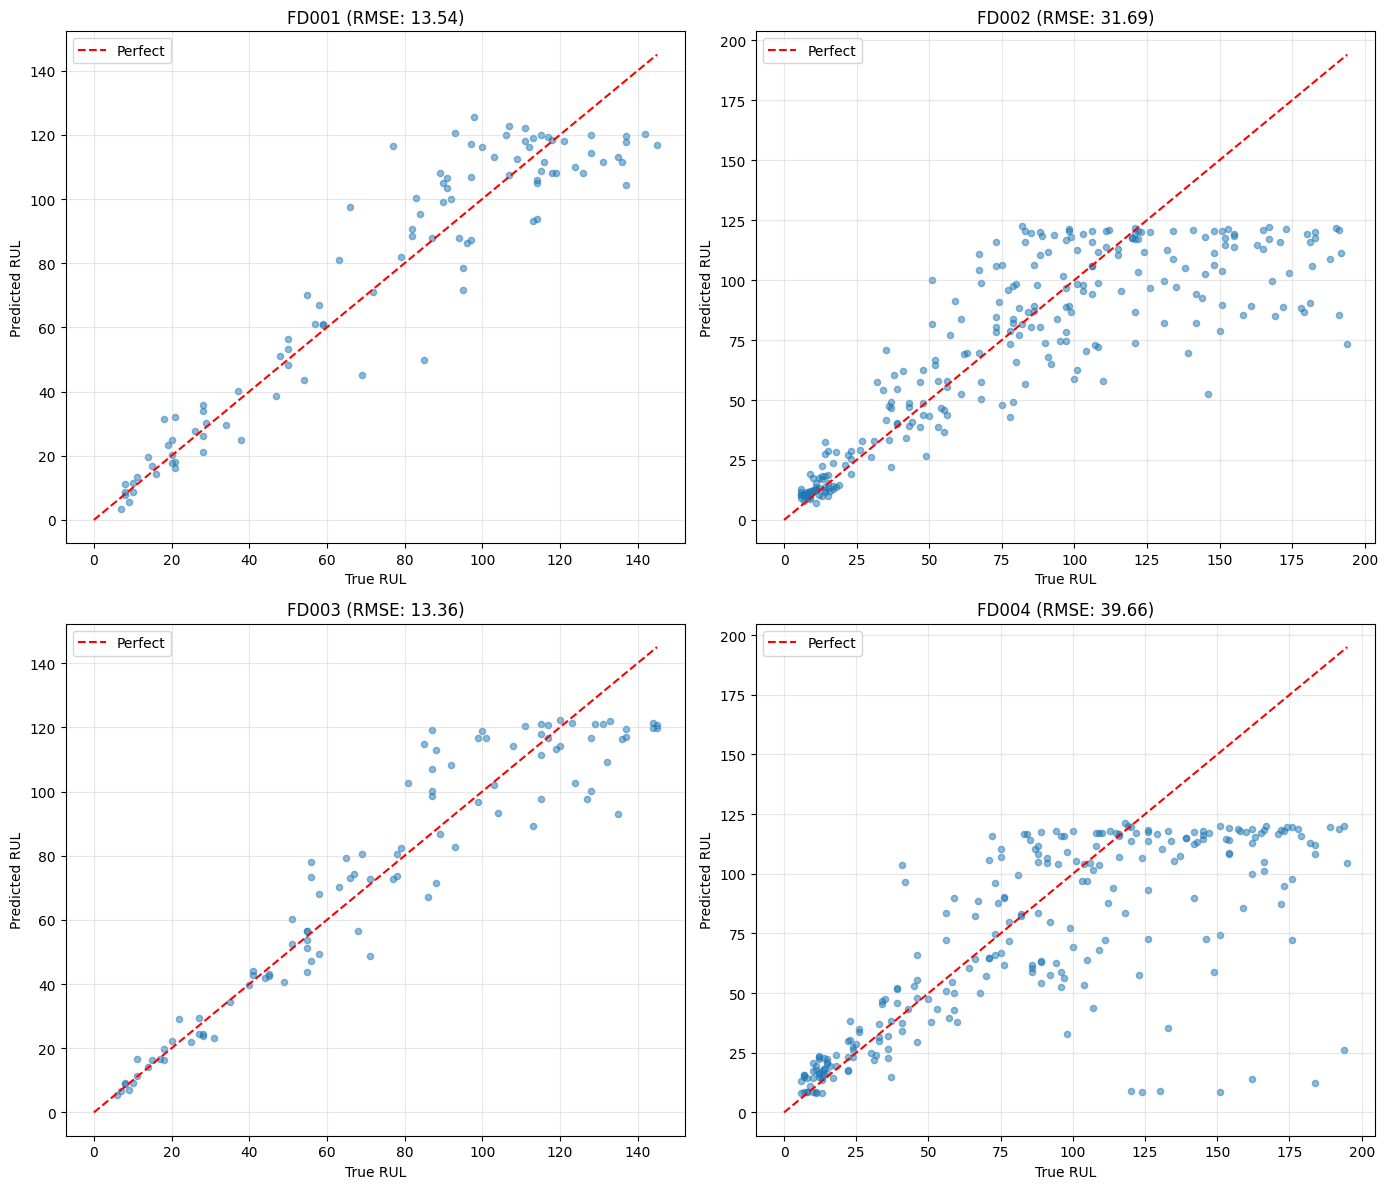

In [29]:
# Predictions vs True RUL for all datasets
fig, axes = plt.subplots(2, 2, figsize=(14, 12))
axes = axes.flatten()

for idx, dataset in enumerate(datasets_with_results):
    if idx >= 4:
        break

    preds = all_results[dataset]['predictions']
    targs = all_results[dataset]['targets']
    rmse = all_results[dataset]['metrics']['RMSE']

    axes[idx].scatter(targs, preds, alpha=0.5, s=20)
    max_val = max(max(targs), max(preds))
    axes[idx].plot([0, max_val], [0, max_val], 'r--', label='Perfect')
    axes[idx].set_xlabel('True RUL')
    axes[idx].set_ylabel('Predicted RUL')
    axes[idx].set_title(f'{dataset} (RMSE: {rmse:.2f})')
    axes[idx].legend()
    axes[idx].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/abgru_predictions_all_datasets.png', dpi=150, bbox_inches='tight')
plt.show()

In [30]:
# Save summary to CSV (including F1 scores)
# Regression metrics
summary_df.to_csv('/content/drive/MyDrive/abgru_regression_results.csv', index=False)
print("Regression results saved to abgru_regression_results.csv")

# Binary classification metrics
binary_df.to_csv('/content/drive/MyDrive/abgru_binary_classification_results.csv', index=False)
print("Binary classification results saved to abgru_binary_classification_results.csv")

# Multi-class classification metrics
multi_df.to_csv('/content/drive/MyDrive/abgru_multiclass_results.csv', index=False)
print("Multi-class results saved to abgru_multiclass_results.csv")

# Combined summary
combined_data = []
for dataset in datasets_with_results:
    m = all_results[dataset]['metrics']
    combined_data.append({
        'Dataset': dataset,
        'RMSE': m['RMSE'],
        'MAE': m['MAE'],
        'R2': m['R2'],
        'Score': m['Score'],
        'Binary_F1': m['Binary_F1'],
        'Binary_Precision': m['Binary_Precision'],
        'Binary_Recall': m['Binary_Recall'],
        'Multi_F1_Macro': m['Multi_F1_Macro'],
        'Multi_F1_Weighted': m['Multi_F1_Weighted'],
        'F1_Critical': m['F1_Critical'],
        'F1_Warning': m['F1_Warning'],
        'F1_Normal': m['F1_Normal']
    })
combined_df = pd.DataFrame(combined_data)
combined_df.to_csv('/content/drive/MyDrive/abgru_all_metrics.csv', index=False)
print("Complete metrics saved to abgru_all_metrics.csv")

# Save individual predictions for each dataset
for dataset in datasets_with_results:
    results_df = pd.DataFrame({
        'Engine': range(1, len(all_results[dataset]['targets']) + 1),
        'True_RUL': all_results[dataset]['targets'],
        'Predicted_RUL': all_results[dataset]['predictions'],
        'Error': all_results[dataset]['predictions'] - all_results[dataset]['targets'],
        'True_Class': all_results[dataset]['metrics']['y_true_multi'],
        'Predicted_Class': all_results[dataset]['metrics']['y_pred_multi']
    })
    results_df.to_csv(f'/content/drive/MyDrive/abgru_predictions_{dataset}.csv', index=False)
    print(f"Predictions saved for {dataset}")

# Save models
for dataset in datasets_with_results:
    model_path = f'/content/drive/MyDrive/abgru_model_{dataset}.pth'
    torch.save({
        'model_state_dict': all_results[dataset]['model'].state_dict(),
        'metrics': {k: v for k, v in all_results[dataset]['metrics'].items()
                   if k not in ['confusion_matrix', 'y_true_multi', 'y_pred_multi']},
        'config': config
    }, model_path)
    print(f"Model saved for {dataset}")

Regression results saved to abgru_regression_results.csv
Binary classification results saved to abgru_binary_classification_results.csv
Multi-class results saved to abgru_multiclass_results.csv
Complete metrics saved to abgru_all_metrics.csv
Predictions saved for FD001
Predictions saved for FD002
Predictions saved for FD003
Predictions saved for FD004
Model saved for FD001
Model saved for FD002
Model saved for FD003
Model saved for FD004


# Final Summary Table with all metrics
print("\n" + "="*120)
print("FINAL RESULTS - ABGRU ON CMAPSS DATASETS")
print("="*120)

print("\n--- REGRESSION METRICS ---")
print(f"{'Dataset':<10} {'RMSE':<10} {'MAE':<10} {'R2':<10} {'Score':<10}")
print("-"*50)
for dataset in datasets_with_results:
    m = all_results[dataset]['metrics']
    print(f"{dataset:<10} {m['RMSE']:<10.2f} {m['MAE']:<10.2f} {m['R2']:<10.4f} {m['Score']:<10.2f}")

print("\n--- BINARY F1 SCORES (Failure within 30 cycles) ---")
print(f"{'Dataset':<10} {'Accuracy':<12} {'Precision':<12} {'Recall':<12} {'F1':<12}")
print("-"*60)
for dataset in datasets_with_results:
    m = all_results[dataset]['metrics']
    print(f"{dataset:<10} {m['Binary_Accuracy']:<12.4f} {m['Binary_Precision']:<12.4f} {m['Binary_Recall']:<12.4f} {m['Binary_F1']:<12.4f}")

print("\n--- MULTI-CLASS F1 SCORES (Critical/Warning/Normal) ---")
print(f"{'Dataset':<10} {'F1 Macro':<12} {'F1 Weighted':<14} {'F1 Critical':<14} {'F1 Warning':<14} {'F1 Normal':<12}")
print("-"*80)
for dataset in datasets_with_results:
    m = all_results[dataset]['metrics']
    print(f"{dataset:<10} {m['Multi_F1_Macro']:<12.4f} {m['Multi_F1_Weighted']:<14.4f} {m['F1_Critical']:<14.4f} {m['F1_Warning']:<14.4f} {m['F1_Normal']:<12.4f}")

print("\n" + "="*120)
print("Classification Thresholds:")
print("  - Critical: RUL < 30 cycles (imminent failure)")
print("  - Warning:  30 <= RUL < 60 cycles (approaching failure)")
print("  - Normal:   RUL >= 60 cycles (healthy operation)")
print("="*120)

print("\nDataset Characteristics:")
print("-"*60)
print("FD001: 1 operating condition, 1 fault mode (simplest)")
print("FD002: 6 operating conditions, 1 fault mode")
print("FD003: 1 operating condition, 2 fault modes")
print("FD004: 6 operating conditions, 2 fault modes (most complex)")
print("="*120)

In [31]:
# Save summary to CSV
summary_df.to_csv('/content/drive/MyDrive/abgru_results_summary.csv', index=False)
print("Summary saved to abgru_results_summary.csv")

# Save individual predictions for each dataset
for dataset in datasets_with_results:
    results_df = pd.DataFrame({
        'Engine': range(1, len(all_results[dataset]['targets']) + 1),
        'True_RUL': all_results[dataset]['targets'],
        'Predicted_RUL': all_results[dataset]['predictions'],
        'Error': all_results[dataset]['predictions'] - all_results[dataset]['targets']
    })
    results_df.to_csv(f'/content/drive/MyDrive/abgru_predictions_{dataset}.csv', index=False)
    print(f"Predictions saved for {dataset}")

# Save models
for dataset in datasets_with_results:
    model_path = f'/content/drive/MyDrive/abgru_model_{dataset}.pth'
    torch.save({
        'model_state_dict': all_results[dataset]['model'].state_dict(),
        'metrics': all_results[dataset]['metrics'],
        'config': config
    }, model_path)
    print(f"Model saved for {dataset}")

Summary saved to abgru_results_summary.csv
Predictions saved for FD001
Predictions saved for FD002
Predictions saved for FD003
Predictions saved for FD004
Model saved for FD001
Model saved for FD002
Model saved for FD003
Model saved for FD004


In [32]:
# Final Summary Table
print("\n" + "="*80)
print("FINAL RESULTS - ABGRU ON CMAPSS DATASETS")
print("="*80)
print(f"\n{'Dataset':<10} {'RMSE':<10} {'MAE':<10} {'R2':<10} {'Score':<10}")
print("-"*50)
for dataset in datasets_with_results:
    m = all_results[dataset]['metrics']
    print(f"{dataset:<10} {m['RMSE']:<10.2f} {m['MAE']:<10.2f} {m['R2']:<10.4f} {m['Score']:<10.2f}")
print("="*80)

print("\nDataset Characteristics:")
print("-"*50)
print("FD001: 1 operating condition, 1 fault mode")
print("FD002: 6 operating conditions, 1 fault mode")
print("FD003: 1 operating condition, 2 fault modes")
print("FD004: 6 operating conditions, 2 fault modes")
print("="*80)


FINAL RESULTS - ABGRU ON CMAPSS DATASETS

Dataset    RMSE       MAE        R2         Score     
--------------------------------------------------
FD001      13.54      10.32      0.8938     279.85    
FD002      31.69      21.36      0.6527     25719.09  
FD003      13.36      9.73       0.8958     242.97    
FD004      39.66      26.05      0.4709     1126946.50

Dataset Characteristics:
--------------------------------------------------
FD001: 1 operating condition, 1 fault mode
FD002: 6 operating conditions, 1 fault mode
FD003: 1 operating condition, 2 fault modes
FD004: 6 operating conditions, 2 fault modes
